# Automated Characterization of the Dynamic Comparator
---
**Author:** Antigravity AI Partner  \
**PDK:** GF180MCU 3.3 V  \
**Tools:** ngspice + Python (Jupyter)

Extracts three key metrics in **one** transient simulation run from
`tb_strongARM_offset.spice` (generated by XSchem):

1. **Propagation Delay ($t_{pd}$)** — CLK fall edge to output 50% crossing
2. **Dynamic Offset Voltage ($V_{OS}$)** — input-referred switching error
3. **Average Power ($P_{avg}$)** — dynamic supply current integrated over time


In [1]:
import os          # File-system operations (path checks, makedirs)
import subprocess  # Run external processes (xschem, ngspice)
import re          # Regular expressions — parse ngspice measurement output
import numpy as np # Numerical arrays for waveform data

SCH_NAME = 'tb_strongARM_offset'

# ── Project paths (inside the iic-osic-tools Docker container) ───────────────
PDK_PATH = '/foss/pdks/gf180mcuD'


# Destination for the XSchem-generated netlist (.spice)
# NOTE: Without the '-o' flag, XSchem defaults to:
#   /headless/.xschem/simulations/tb_strongARM_offset.spice
# Cell 3 uses '-o SIM_DIR' to redirect output here.
#  Depending on the configuration, I sometimes use this path:
#'/foss/designs/Chipathon-2026-OnChipSAR/designs/sar_adc/comparator/Testbench/simulation/'
SIM_DIR = '/headless/.xschem/simulations'

# Directory where ngspice writes the ASCII raw waveform file
RAW_DIR = '/headless/.xschem/simulations'

# Create the raw directory if it does not already exist
os.makedirs(RAW_DIR, exist_ok=True)


In [2]:
class NgspiceRawReader:
    # Minimal ASCII raw-file reader for ngspice transient simulations.
    # When '.control / set filetype=ascii / .endc' is used in the netlist,
    # ngspice writes waveform data in a plain-text 'raw' format. This class
    # parses that file and exposes each signal as a NumPy array.

    def __init__(self, filepath):
        self.filepath  = filepath   # Absolute path to the .raw file
        self.variables = []         # Ordered list of signal names, e.g. 'v(clk)'
        self.data      = {}         # Dict: signal_name -> NumPy float array
        self.load()                 # Parse immediately on construction

    def load(self):
        # Fail early with a clear message if the file is missing
        if not os.path.exists(self.filepath):
            raise FileNotFoundError(f"Raw file not found: {self.filepath}")

        with open(self.filepath, 'r') as f:
            lines = f.readlines()

        # ── Step 1: parse the Variables: block ───────────────────────────────
        # Format:  <index>  <signal_name>  <type>   (one line per signal)
        data_start = 0
        j = 0
        for idx, line in enumerate(lines):
            if line.startswith('Variables:'):
                j = idx + 1
                while not lines[j].startswith('Values:'):
                    parts = lines[j].strip().split()
                    if len(parts) >= 3:
                        self.variables.append(parts[1])  # Keep only the name
                    j += 1
            if line.startswith('Values:'):
                data_start = j + 1  # Numeric data starts one line after 'Values:'
                break

        # ── Step 2: allocate an empty list for each signal ────────────────────
        for var in self.variables:
            self.data[var] = []

        # ── Step 3: parse the data block ─────────────────────────────────────
        # Each time-point is written as:
        #   <point_index>  <time_value>   <- first line (two tokens)
        #   <signal_1_value>              <- one per subsequent line
        i = data_start
        while i < len(lines):
            line = lines[i].strip()
            if not line:
                i += 1
                continue
            parts = line.split()
            if len(parts) == 2:   # First row of a new time-point
                self.data[self.variables[0]].append(float(parts[1]))  # time
                for v_idx in range(1, len(self.variables)):
                    self.data[self.variables[v_idx]].append(float(lines[i + v_idx].strip()))
                i += len(self.variables)
            else:
                i += 1

        # ── Step 4: convert Python lists to NumPy arrays ──────────────────────
        for var in self.variables:
            self.data[var] = np.array(self.data[var])

    def get_signal(self, name):
        # Return the NumPy array for a signal by name (case-insensitive).
        for var in self.variables:
            if var.lower() == name.lower():
                return self.data[var]
        raise KeyError(f"Signal '{name}' not found. Available: {self.variables}")

# Run the simulation with Ngspice.
---



In [3]:
import re
import os
import subprocess


# Original netlist generated by XSchem 
spice_file_orig = os.path.join(SIM_DIR, f'{SCH_NAME}.spice')

# Temporary copy with the .control block appended — deleted immediately after the run
spice_file_run  = f'/tmp/{SCH_NAME}_run.spice'

# Output raw waveform file written by ngspice in ASCII format
raw_file = os.path.join(RAW_DIR, f'{SCH_NAME}.raw')


VALID_CORNERS = ('typical', 'ff', 'ss', 'fs', 'sf')

CORNER   = 'typical'
VDD_VAL  = 3.3
TEMP_C   = 27

with open(spice_file_orig, 'r') as f:
    spice_code = f.read()

# Corner (sigue siendo texto de modelo, no .param -> regex necesario)
pattern_corner = r"(\.lib\s+'[^']+'\s+)(\S+)"
spice_code_new, n_corner = re.subn(pattern_corner, r'\g<1>' + CORNER, spice_code, flags=re.IGNORECASE)
if n_corner == 0:
    raise RuntimeError("No se encontró la línea .lib con comillas simples.")
print(f"   Corner: {CORNER} ({n_corner} reemplazo(s))")

control_code = (
    "\n.control\n"
    "  set filetype=ascii\n"
    f"  alterparam VDD = {VDD_VAL}\n"
    "  reset\n"
    f"  option temp={TEMP_C}\n"
    "  run\n"
    f"  write {raw_file}\n"
    "  quit\n"
    ".endc\n"
)

with open(spice_file_run, 'w') as f:
    f.write(spice_code_new + "\n" + control_code)

print("2. Running ngspice (batch mode) ...")
res = subprocess.run(
    ['/foss/tools/ngspice/bin/ngspice', '-b', spice_file_run],
    capture_output=True, text=True, check=True
)

try:
    os.remove(spice_file_run)
except Exception:
    pass

sim_stdout = res.stdout

print("finalized")

   Corner: typical (1 reemplazo(s))
2. Running ngspice (batch mode) ...
finalized


## Cell 4 — Single Simulation: Delay + Offset + Power

One ngspice run extracts all three metrics. Results are parsed from the
`.measure` output lines. Waveforms are loaded from the ASCII raw file.

### Propagation Delay $t_{pd}$
$$t_{pd} = t\left(v(O_N)=1.65\,\text{V}\right) - t\left(v(CLK)=1.65\,\text{V}\right)$$



>>> Propagation delay: 881.40 ps


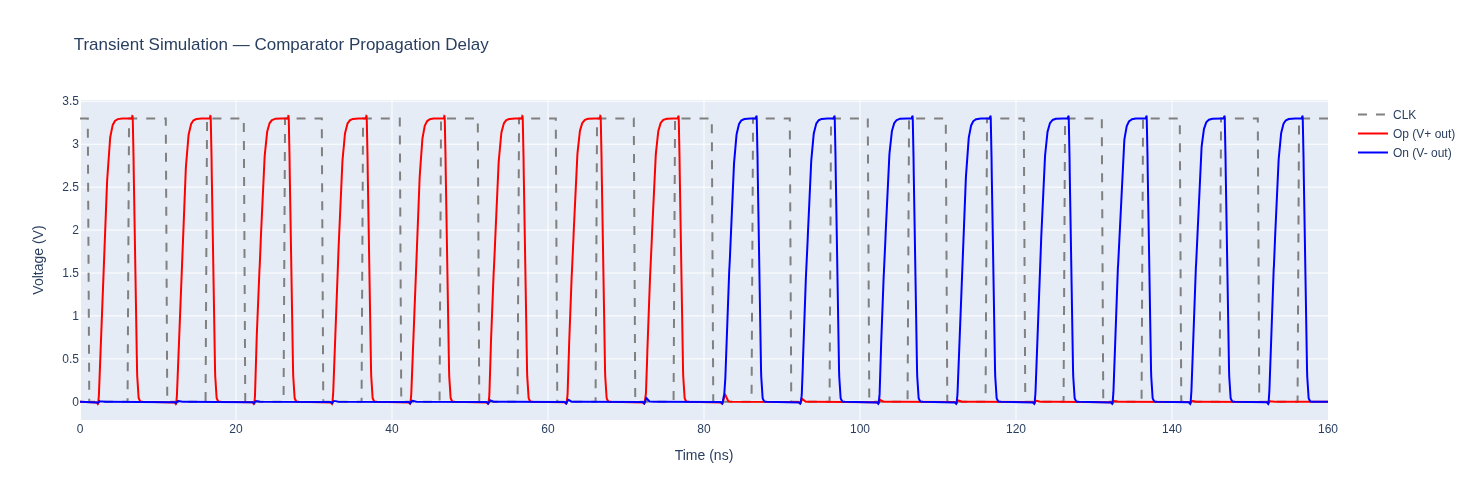

In [4]:
import re          # Parse measurement values from ngspice stdout
import numpy as np # Numerical operations on waveform arrays
import plotly.graph_objects as go  # Interactive plotting
# ── Parse propagation delay ───────────────────────────────────────────────────
# ngspice prints:  tpd_ON  =  2.136216e-08  targ=...  trig=...
tpd_match = re.search(r'tpd_on\s*=\s*([0-9e.+\-]+)', res.stdout, re.IGNORECASE)
if tpd_match:
    tpd_val = float(tpd_match.group(1)) * 1e12  # seconds -> picoseconds
    print(f"\n>>> Propagation delay: {tpd_val:.2f} ps")
else:
    print("\nWarning: tpd_ON not found in ngspice output.")

# ── Load waveforms from the ASCII raw file ────────────────────────────────────
reader = NgspiceRawReader(raw_file)
time   = reader.get_signal('time') * 1e9   # ns
vclk   = reader.get_signal('v(clk)')       # Clock waveform
vop    = reader.get_signal('v(op)')         # Positive output (Op)
von    = reader.get_signal('v(on)')         # Negative output (On) — falls when VIP > VIN

# ── Plot: transient waveforms ─────────────────────────────────────────────────
fig = go.Figure()

# Clock — dashed gray reference
fig.add_trace(go.Scatter(x=time, y=vclk, name='CLK',
                         line=dict(color='gray', dash='dash')))
# Positive output
fig.add_trace(go.Scatter(x=time, y=vop, name='Op (V+ out)',
                         line=dict(color='red', width=2)))
# Negative output — the delay is measured to its 50% crossing
fig.add_trace(go.Scatter(x=time, y=von, name='On (V- out)',
                         line=dict(color='blue', width=2)))

fig.update_layout(
    title='Transient Simulation — Comparator Propagation Delay',
    xaxis_title='Time (ns)',
    yaxis_title='Voltage (V)',
    hovermode='x unified',
    height=500, width=1000
)
fig.show()

## Cell 5 — Dynamic Offset Voltage ($V_{OS}$)

The offset is the horizontal shift between the VIP ramp crossing point and the
ideal common-mode voltage $V_{CM}$:

$$V_{OS} = V_{IP,\text{cross}} - V_{CM}$$

Reuses `sim_stdout` and `raw_file` from **Cell 4** — no new simulation.



>>> VIP crossing point : 1.6512 V
>>> Dynamic offset Vos : 1.24 mV


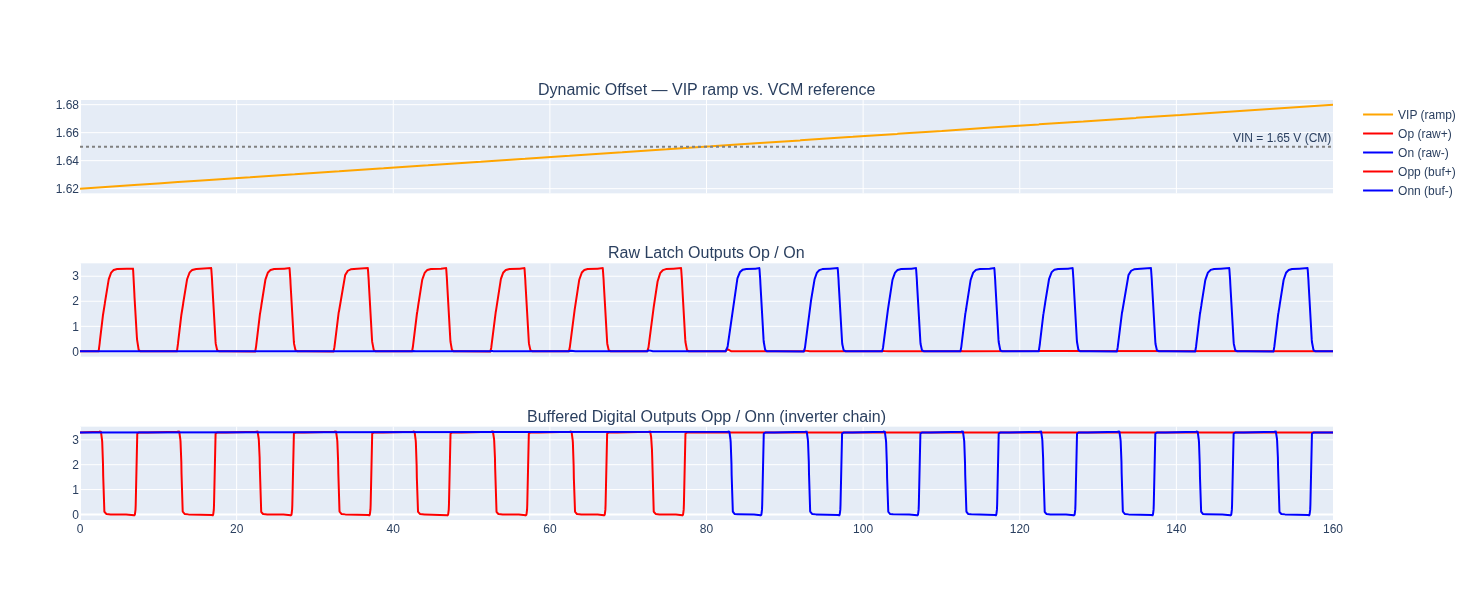

In [5]:
import re
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Parse offset measurements from the cached ngspice output ─────────────────
# ngspice prints:  vvip_cross  =  1.667402e+00  (VIP value when On crosses 50%)
cross_match = re.search(r'vvip_cross\s*=\s*([0-9e.+\-]+)', sim_stdout, re.IGNORECASE)
# ngspice prints:  ofset  =  1.74022e-02  (= vvip_cross - vcm)
ofset_match = re.search(r'ofset\s*=\s*([0-9e.+\-]+)', sim_stdout, re.IGNORECASE)

if ofset_match:
    ofset_val = float(ofset_match.group(1)) * 1e3   # V -> mV
    cross_val = float(cross_match.group(1))
    print(f"\n>>> VIP crossing point : {cross_val:.4f} V")
    print(f">>> Dynamic offset Vos : {ofset_val:.2f} mV")
else:
    print("\nWarning: 'ofset' not found in ngspice output.")

# ── Reload waveforms from the same raw file (no new simulation) ───────────────
reader = NgspiceRawReader(raw_file)
time   = reader.get_signal('time') * 1e9    # ns
vclk   = reader.get_signal('v(clk)')
vop    = reader.get_signal('v(op)')
von    = reader.get_signal('v(on)')
vvip   = reader.get_signal('v(vip)')        # VIP input ramp
vopp   = reader.get_signal('v(opp)')        # Buffered positive output
vonn   = reader.get_signal('v(onn)')        # Buffered negative output

# ── Three-panel plot ──────────────────────────────────────────────────────────
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,   # Synchronized zoom across all panels
    subplot_titles=(
        'Dynamic Offset — VIP ramp vs. VCM reference',
        'Raw Latch Outputs Op / On',
        'Buffered Digital Outputs Opp / Onn (inverter chain)'
    )
)

# Panel 1: VIP ramp + VCM reference line
fig.add_trace(go.Scatter(x=time, y=vvip, name='VIP (ramp)',
                         line=dict(color='orange', width=2)), row=1, col=1)
# The offset is visible as the gap between this line and the actual crossing point
fig.add_hline(y=1.65, line_dash='dot', line_color='gray',
              annotation_text='VIN = 1.65 V (CM)', row=1, col=1)

# Panel 2: raw latch nodes
fig.add_trace(go.Scatter(x=time, y=vop, name='Op (raw+)',
                         line=dict(color='red')),  row=2, col=1)
fig.add_trace(go.Scatter(x=time, y=von, name='On (raw-)',
                         line=dict(color='blue')), row=2, col=1)

# Panel 3: digital outputs after the 10-stage inverter chain
fig.add_trace(go.Scatter(x=time, y=vopp, name='Opp (buf+)',
                         line=dict(color='red')),  row=3, col=1)
fig.add_trace(go.Scatter(x=time, y=vonn, name='Onn (buf-)',
                         line=dict(color='blue')), row=3, col=1)

fig.update_layout(hovermode='x unified', height=600, width=1000)
fig.show()

## Cell 6 — Average Power Consumption ($P_{avg}$)

StrongARM latch has zero static current — all power is dynamic (brief
current spikes during evaluation and reset phases).

$$P_{avg} = V_{DD} \cdot I_{avg}$$

Reuses `sim_stdout` and `raw_file` from **Cell 4**.



>>> Average power: 147.279 uW


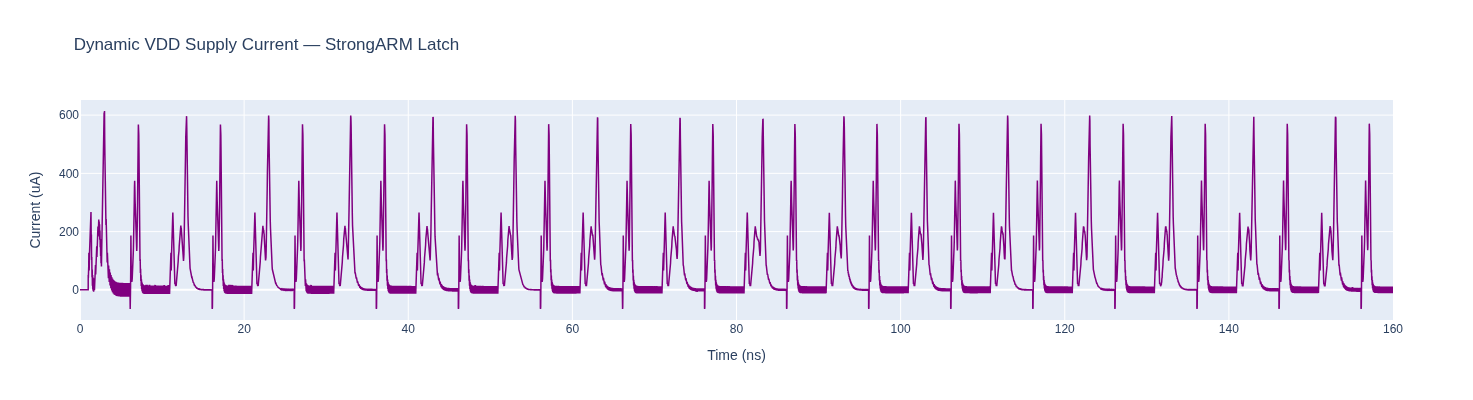

In [6]:


import re
import plotly.graph_objects as go

# ── Parse average power from the cached ngspice output ───────────────────────
# ngspice prints:  p_avg  =  1.34392e-04  (in watts)
pavg_match = re.search(r'p_avg\s*=\s*([0-9e.+\-]+)', sim_stdout, re.IGNORECASE)
if pavg_match:
    pavg_val = float(pavg_match.group(1)) * 1e6   # W -> uW
    print(f"\n>>> Average power: {pavg_val:.3f} uW")
else:
    print("\nWarning: 'p_avg' not found in ngspice output.")

# ── Load VDD supply current from the raw file ─────────────────────────────────
reader = NgspiceRawReader(raw_file)
time   = reader.get_signal('time') * 1e9      # ns
# i(v1) convention: positive = current into V+ terminal of source
# Negate to get current delivered to the circuit, scale to uA
i_v1   = -reader.get_signal('i(v1)') * 1e6

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=time, y=i_v1,
    name='VDD Supply Current',
    line=dict(color='purple', width=1.5)
))

# The pulsed shape is the StrongARM signature:
#   spike on CLK rise  -> tail transistor on, internal nodes charge
#   spike on CLK fall  -> reset, transistors cut off
#   zero between spikes -> zero static power
fig.update_layout(
    title='Dynamic VDD Supply Current — StrongARM Latch',
    xaxis_title='Time (ns)',
    yaxis_title='Current (uA)',
    hovermode='x unified',
    height=400, width=1000
)
fig.show()